<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_csv("/content/exchange_rate.csv")

In [3]:
def plot_time_series(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df['date'], df['Ex_rate'], label='Exchange Rate (USD to AUD)', color='blue')
    plt.xlabel('Date')
    plt.ylabel('Exchange Rate')
    plt.title('Historical Exchange Rate (USD to AUD)')
    plt.legend()
    plt.grid(True)
    plt.show()


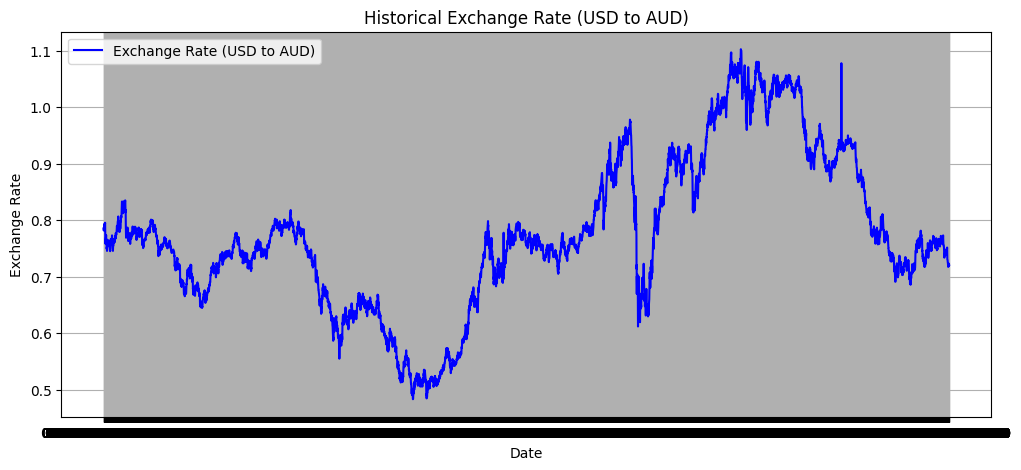

In [4]:
plot_time_series(df)

# Check stationarity


In [9]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:', result[4])
    return result[1]

In [10]:
print("ADF Test Before Differencing:")
adf_test(df['Ex_rate'])


ADF Test Before Differencing:
ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Critical Values: {'1%': np.float64(-3.4312123140180137), '5%': np.float64(-2.861921078147796), '10%': np.float64(-2.5669728434336108)}


np.float64(0.4492327353597477)

# Differencing to achieve stationarity

In [12]:
df['Ex_rate_diff'] = df['Ex_rate'].diff()
print("ADF Test After Differencing:")
adf_test(df['Ex_rate_diff'].dropna())

ADF Test After Differencing:
ADF Statistic: -99.39343120118632
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4312123140180137), '5%': np.float64(-2.861921078147796), '10%': np.float64(-2.5669728434336108)}


0.0

# ACF and PACF plots


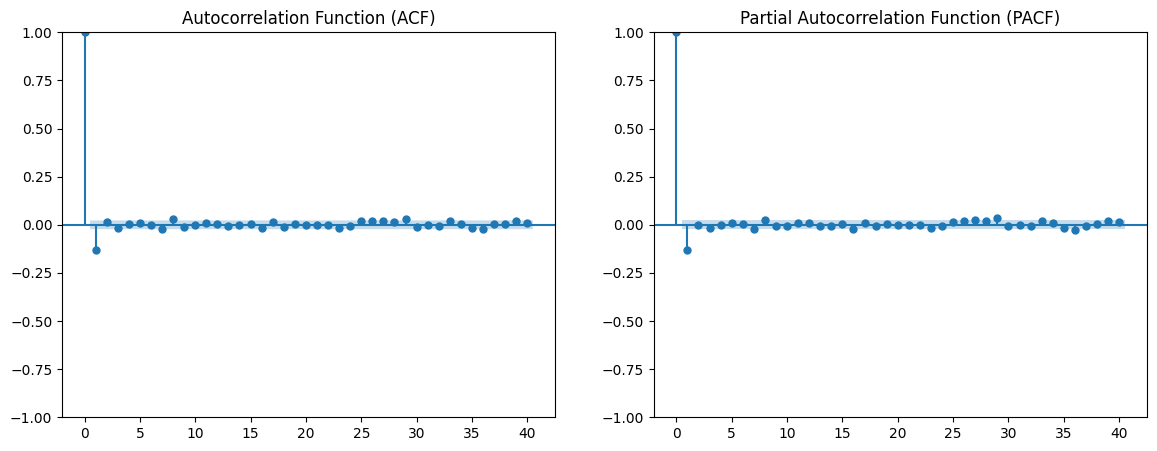

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['Ex_rate_diff'].dropna(), ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['Ex_rate_diff'].dropna(), ax=axes[1], lags=40, method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")
plt.show()


# Fit ARIMA model


In [16]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(df['Ex_rate'], order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sun, 30 Mar 2025   AIC                         -56102.322
Time:                        17:05:46   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

# Residual diagnostics

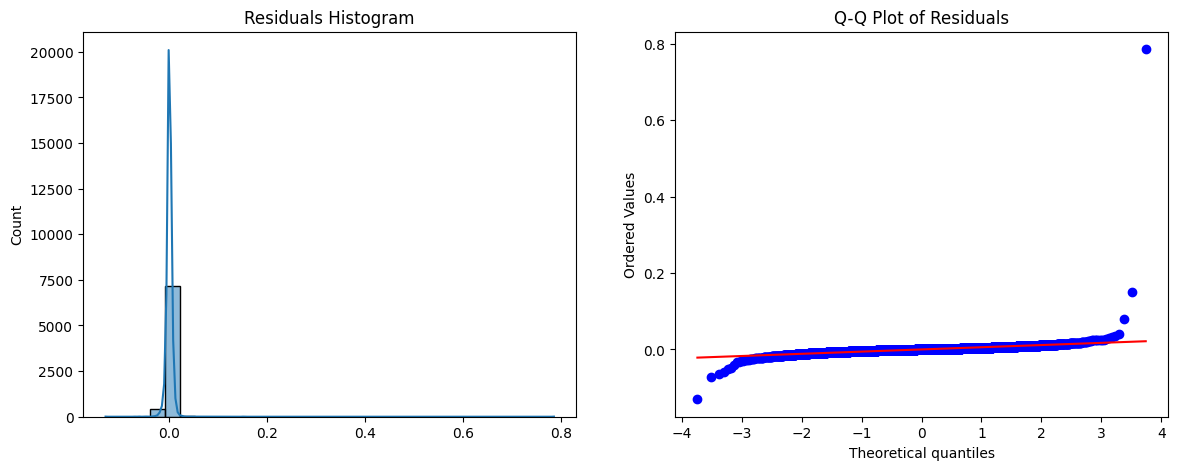

In [20]:

residuals = arima_fit.resid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Residuals Histogram")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.show()


<Figure size 1000x400 with 0 Axes>

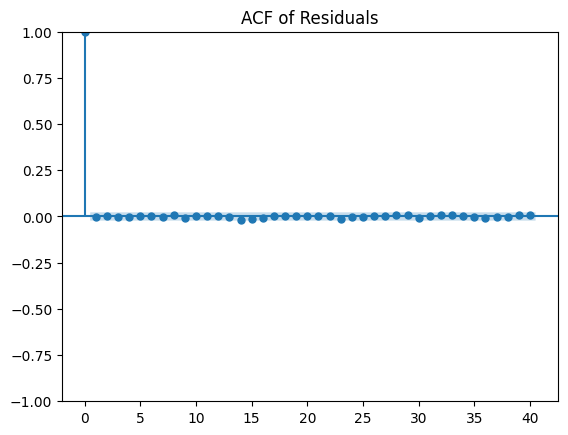

In [21]:

plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=40)
plt.title("ACF of Residuals")
plt.show()


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Forecast with ARIMA

In [34]:
forecast_steps = 30
forecast = arima_fit.forecast(steps=forecast_steps)
future_dates = pd.date_range(start=df['date'].iloc[-1], periods=forecast_steps+1, freq="D")[1:]


# Forecast with ARIMA


In [48]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y %H:%M")

# Generate future dates for plotting
future_dates = pd.date_range(start=df["date"].max(), periods=len(forecast) + 1, freq="D")[1:]


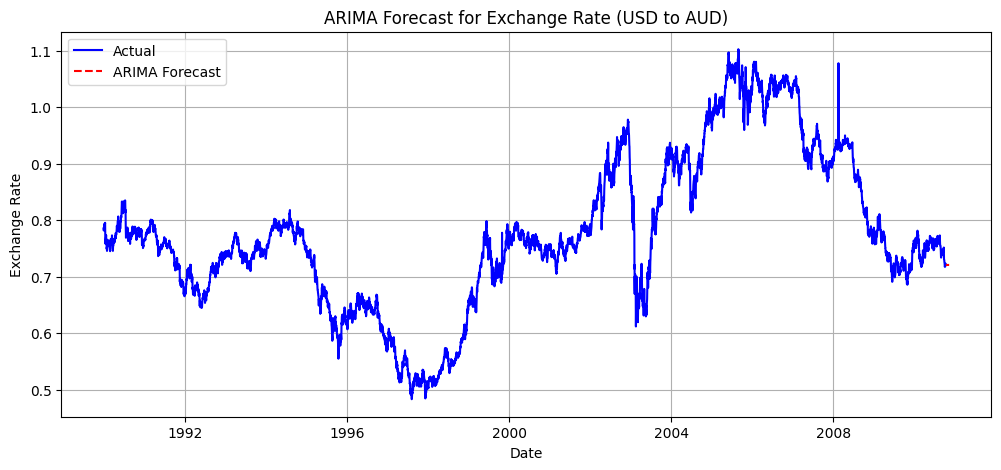

In [49]:
forecast_steps = 30
forecast = arima_fit.forecast(steps=forecast_steps)
future_dates = pd.date_range(start=df['date'].iloc[-1], periods=forecast_steps+1, freq="D")[1:]
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['Ex_rate'], label='Actual', color='blue')
plt.plot(future_dates, forecast, label='ARIMA Forecast', color='red', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.title("ARIMA Forecast for Exchange Rate (USD to AUD)")
plt.legend()
plt.grid(True)
plt.show()

# Fit Exponential Smoothing model

In [39]:
hw_model = ExponentialSmoothing(df['Ex_rate'], trend='add', seasonal=None).fit()
hw_forecast = hw_model.forecast(steps=forecast_steps)

# Compare forecasts


In [46]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y %H:%M")

# Generate future dates for plotting
future_dates = pd.date_range(start=df["date"].max(), periods=len(forecast) + 1, freq="D")[1:]


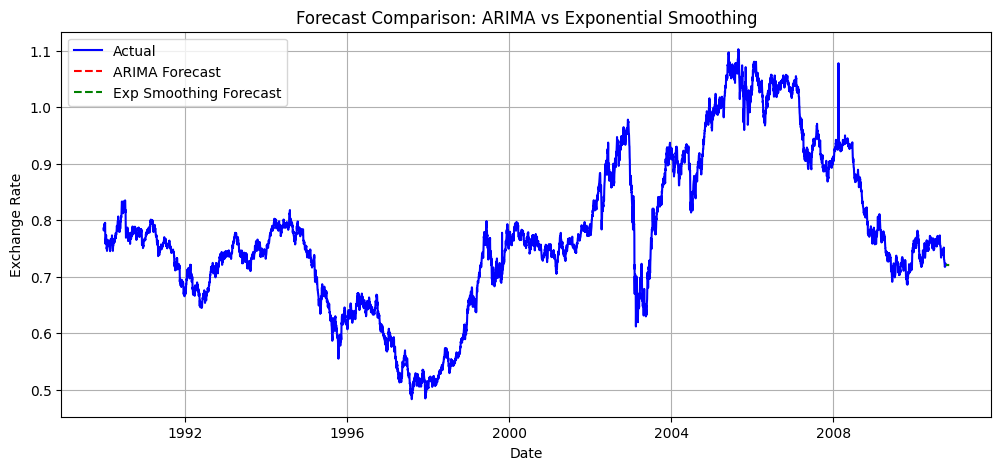

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['Ex_rate'], label='Actual', color='blue')
plt.plot(future_dates, forecast, label='ARIMA Forecast', color='red', linestyle='dashed')
plt.plot(future_dates, hw_forecast, label='Exp Smoothing Forecast', color='green', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.title("Forecast Comparison: ARIMA vs Exponential Smoothing")
plt.legend()
plt.grid(True)
plt.show()


# Evaluation metrics

In [40]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} RMSE: {rmse:.4f}")



In [37]:
y_true = df['Ex_rate'].iloc[-forecast_steps:]
evaluate(y_true, forecast[:len(y_true)], "ARIMA")
evaluate(y_true, hw_forecast[:len(y_true)], "Exponential Smoothing")


ARIMA MAE: 0.0127
ARIMA RMSE: 0.0170
Exponential Smoothing MAE: 0.0128
Exponential Smoothing RMSE: 0.0170
